This script loads in the data and runs all analysis on it. Make Task= "A" if you want to test binary Real/AI images, and make Task = "B" if you want to test classifying different AI models. The final 2 cells load in the dataset in the form of pixel values, but these are optional and take a long time to load. The whole script prior to that can take between 1-2 hours to run on a GPU, which we highly recommend. Feel free to alter the number of epochs if you desire a faster or more thoroughly trained model.

In [ ]:
from datasets import load_dataset #importing all needed packages
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
import torch.optim as optim
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

ds = load_dataset("Rajarshi-Roy-research/Defactify_Image_Dataset") # from dataset link; loads in images

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/validation-00000-of-00002.parquet:   0%|          | 0.00/333M [00:00<?, ?B/s]

data/validation-00001-of-00002.parquet:   0%|          | 0.00/345M [00:00<?, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

...

data/test-00004-of-00006.parquet:   0%|          | 0.00/574M [00:00<?, ?B/s]

data/test-00005-of-00006.parquet:   0%|          | 0.00/600M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/42000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/45000 [00:00<?, ? examples/s]

In [ ]:
ds

DatasetDict({
    validation: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 9000
    })
    train: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 42000
    })
    test: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 45000
    })
})

In [ ]:
# "A" = binary (Label_A)
# "B" = 6-class (Label_B)
TASK = "B"

In [ ]:
weights = models.ConvNeXt_Tiny_Weights.DEFAULT # pre trained weights
preprocess = weights.transforms() # gets preprocessing pipeline of the weights

In [ ]:
def make_transform(task="A"): # converts images to tensors using ConvNeXt preprocessing and sets proper labels
    def transform(batch):
        images = [img.convert("RGB") for img in batch["Image"]]
        batch["pixel_values"] = [preprocess(img) for img in images] # pixel values

        if task == "A": # binary
            batch["labels"] = batch["Label_A"]
        elif task == "B": # 6-class
            batch["labels"] = batch["Label_B"]
        else:
            raise ValueError("task must be 'A' or 'B'")

        return batch
    return transform

In [ ]:
ds_task = ds.with_transform(make_transform(TASK)) # apply make_transform preprocessing to dataset

In [ ]:
def collate_fn(batch): # combines list of images into a single batch
    pixel_values = torch.stack([item["pixel_values"] for item in batch]) # stacks image tensors
    labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long) # groups labels into tensors
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
train_loader = DataLoader(
    ds_task["train"],
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
) #feeds the train dataset to the model in batches of batch size 32. Shuffled for randomness in training

val_loader = DataLoader(
    ds_task["validation"],
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
) #feeds the train dataset to the model in batches of batch size 32. NOT shuffled

test_loader = DataLoader(
    ds_task["test"],
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
) #feeds the train dataset to the model in batches of batch size 32. NOT shuffled

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # runs with GPU; significantly faster

In [ ]:
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT) # specific model type; ConvNeXt_Tiny. Faster

num_classes = 2 if TASK == "A" else 6 # adjusts num_classes for task
model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes) # adds final layer that outputs right number of classes

model = model.to(device) # applies GPU if used else CPU

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 180MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss() # loss metric
optimizer = optim.AdamW(model.parameters(), lr=1e-4) # optimizer

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device): # trains one epoch
    model.train() # train
    running_loss = 0.0 # metrics
    correct = 0
    total = 0

    for batch in loader:
        inputs = batch["pixel_values"].to(device) # pixel values / inputs
        labels = batch["labels"].to(device) # labels / expected outputs

        optimizer.zero_grad() # zero gradient
        outputs = model(inputs) # runs model on inputs
        loss = criterion(outputs, labels) # loss metric
        loss.backward()# back propagation
        optimizer.step() # updates weights

        running_loss += loss.item()
        preds = outputs.argmax(dim=1) # argmax ensures the max prob/score class is selected
        correct += (preds == labels).sum().item() # preds == labels then model is correct
        total += labels.size(0)

    return running_loss / len(loader), correct / total # cumulative loss, accuracy

In [ ]:
def evaluate(model, loader, criterion, device): # similar to train_one_epoch but it does NOT update the model it just measures model performance
    model.eval() # eval mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): #NOT used in training, used for evaluation
        for batch in loader:
            inputs = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total

In [ ]:
ds_task["train"][0] #see the pixel values below for one row

{'Caption': 'Two tall giraffe standing next to each other on a  field.',
 'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480>,
 'Label_A': 0,
 'Label_B': 0,
 'pixel_values': tensor([[[ 0.0912, -0.0287, -0.5767,  ..., -1.6384, -1.6384, -1.6555],
          [-0.5767, -0.1999,  0.1426,  ..., -1.6384, -1.6384, -1.6042],
          [-0.6623, -0.4397, -0.3198,  ..., -1.6727, -1.6727, -1.6042],
          ...,
          [ 0.7933, -0.4226, -1.2788,  ..., -1.0219, -1.3815, -1.5014],
          [ 0.3481, -0.0458,  0.4166,  ..., -1.1247, -1.3473, -1.5014],
          [ 0.2453, -0.6281,  0.7077,  ..., -1.1932, -1.2617, -1.3815]],
 
         [[ 0.1877,  0.0476, -0.5651,  ..., -1.3704, -1.3704, -1.3880],
          [-0.5301, -0.1450,  0.1527,  ..., -1.3704, -1.3704, -1.3354],
          [-0.4951, -0.2675, -0.2325,  ..., -1.3529, -1.3704, -1.3004],
          ...,
          [ 0.8179, -0.4076, -1.2304,  ..., -0.8627, -1.2829, -1.4230],
          [ 0.5378,  0.0826,  0.5728,  ..., -0.9328, 

In [ ]:
epochs = 5 # adjust as needed!

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device) # trains
    val_loss, val_acc = evaluate(model, val_loader, criterion, device) # evaluates

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

Epoch 1/5 | Train Loss: 0.1735 | Train Acc: 0.9371 | Val Loss: 0.0883 | Val Acc: 0.9667
Epoch 2/5 | Train Loss: 0.0461 | Train Acc: 0.9840 | Val Loss: 0.0426 | Val Acc: 0.9852
Epoch 3/5 | Train Loss: 0.0296 | Train Acc: 0.9898 | Val Loss: 0.0467 | Val Acc: 0.9833
Epoch 4/5 | Train Loss: 0.0229 | Train Acc: 0.9917 | Val Loss: 0.0532 | Val Acc: 0.9822
Epoch 5/5 | Train Loss: 0.0236 | Train Acc: 0.9919 | Val Loss: 0.0462 | Val Acc: 0.9854


In [ ]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device) # evaluate one more time on test set
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Test Loss: 5.8137 | Test Acc: 0.4500


In [ ]:
def get_preds_and_labels(model, loader, device): # runs model and collects all predicted labels and real labels
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device) # gets labels

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1) #Gets predicted labels

            all_preds.extend(preds.cpu().numpy()) # puts preds in array
            all_labels.extend(labels.cpu().numpy()) # puts labels in array

    return np.array(all_preds), np.array(all_labels) # returns both arrays

In [ ]:
preds, labels = get_preds_and_labels(model, test_loader, device)

cm = confusion_matrix(labels, preds) # numerical confusion matrix; visualized with plt later

In [ ]:
class_names = ["Real", "AI"]
if TASK == "B":
  class_names =  ["Real", "SD21", "SDXL", "SD3", "DALLE3", "Midjourney"] # set up for confusion matrix depending on task

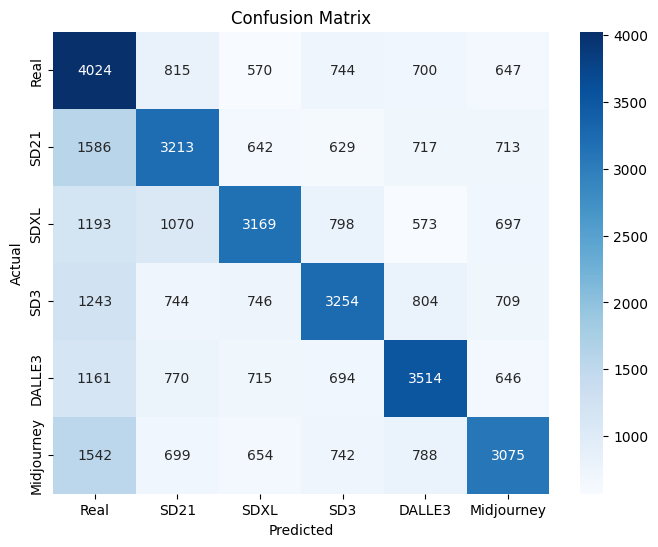

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show() # self explanatory; confusion matrix run

In [22]:
ds_saved = ds.map(
    make_transform(TASK),
    batched=True,
    batch_size=32
) # saves pixel value dataset. TAKES A LONG TIME TO RUN

In [ ]:
ds_saved.save_to_disk("ds_task_saved") # saves it to disk